In [1]:
import litminion as lm

Matplotlib is building the font cache; this may take a moment.


In [2]:
#download + preprocess

lm.set_email("rebecca.sessa@studio.unibo.it")

df = lm.download_pubmed(
    query="JAK inhibitor",
    max_results=10,
)

preprocessor = lm.ClassicalPreprocessor()

processed_documents = [
    preprocessor.transform(text)
    for text in df["Abstract"]
]

In [3]:
#instantiate extractor

extractor = lm.TfidfExtractor()

In [4]:
#fit

matrix = extractor.fit_transform(
    processed_documents
)

In [6]:
#vocab size

features = extractor.get_feature_names()

print(type(features))
print(len(features))
print(features[:10])

<class 'numpy.ndarray'>
751
['001' '005' '0082' '016' '023' '028' '041' '043' '05' '08']


In [7]:
#top terms

extractor.get_top_terms(
    document=0,
    n=15,
)

[('jaki', 0.33981384961992894),
 ('patient', 0.3143120444393691),
 ('involvement', 0.2831782080166075),
 ('bs', 0.26821962613088857),
 ('gastrointestinal', 0.2011647195981664),
 ('slr', 0.2011647195981664),
 ('systematic', 0.2011647195981664),
 ('46', 0.13410981306544428),
 ('and', 0.13410981306544428),
 ('conventional', 0.13410981306544428),
 ('immunosuppressive', 0.13410981306544428),
 ('literature', 0.13410981306544428),
 ('observe', 0.13410981306544428),
 ('or', 0.13410981306544428),
 ('vascular', 0.13410981306544428)]

In [8]:
# to df

df_terms = extractor.to_dataframe(
    document=0,
    n=15,
)

df_terms

,Term,Score
0,jaki,0.339814
1,patient,0.314312
2,involvement,0.283178
3,bs,0.268220
4,gastrointestinal,0.201165
5,slr,0.201165
6,systematic,0.201165
7,46,0.134110
8,and,0.134110
9,conventional,0.134110


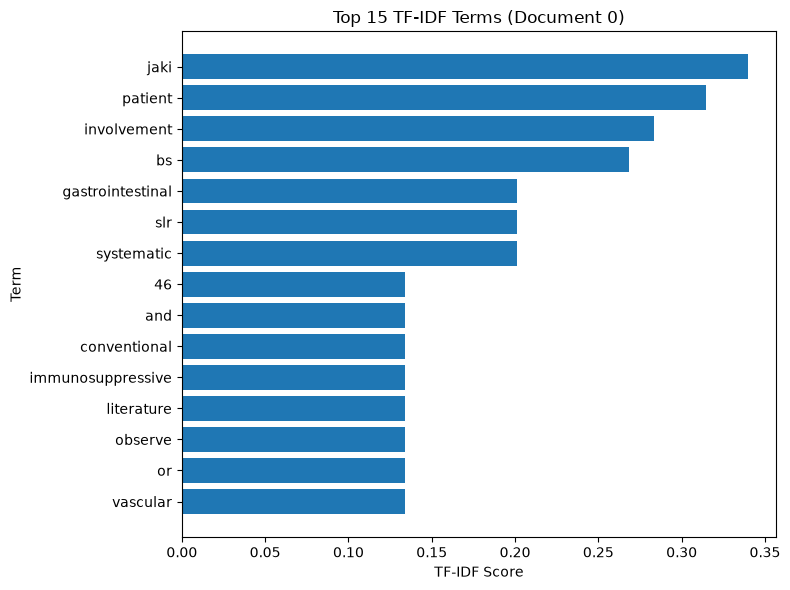

matplotlib.axes._axes.Axes

In [9]:
#plot top terms

ax = extractor.plot_top_terms(
    document=0,
    n=15,
)

type(ax)

In [10]:
#test error 1
try:
    extractor.get_top_terms(999)
except Exception as e:
    print(e)

Document index 999 is out of range. The corpus contains 9 documents.


In [11]:
#test error 2
try:
    extractor.get_top_terms(0, 0)
except Exception as e:
    print(e)

'n' must be greater than zero.
